In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r'C:\Users\Ananya\Downloads\BATTING STATS - IPL_2022.csv')

In [3]:
df.shape

(310, 11)

In [4]:
df.head(15)

,Player,Mat,Inns,Runs,Avg,BF,SR,100,50,4s,6s
0,Jos Buttler,17,17,863,57.53,579,149.05,4,4,83,45
1,Ruturaj Gaikwad,16,16,635,45.35,466,136.26,1,4,64,23
2,Faf du Plessis,16,16,633,45.21,458,138.20,0,6,60,23
3,KL Rahul,13,13,626,62.60,451,138.80,0,6,48,30
4,Shikhar Dhawan,16,16,587,39.13,471,124.62,0,3,63,16
5,Glenn Maxwell,15,14,513,42.75,356,144.10,0,6,48,21
6,Quinton De Kock,15,15,508,36.29,341,148.97,1,3,47,23
7,Hardik Pandya,15,15,487,44.27,371,131.26,0,4,49,12
8,Sanju Samson,14,14,484,40.33,354,136.72,1,2,45,17
9,Shubman Gill,16,16,483,34.50,365,132.32,0,4,51,11


In [5]:
df.fillna(value=0,inplace=True)
print(df)

              Player  Mat  Inns  Runs    Avg   BF      SR  100  50  4s  6s
0        Jos Buttler   17    17   863  57.53  579  149.05    4   4  83  45
1    Ruturaj Gaikwad   16    16   635  45.35  466  136.26    1   4  64  23
2     Faf du Plessis   16    16   633  45.21  458  138.20    0   6  60  23
3           KL Rahul   13    13   626  62.60  451  138.80    0   6  48  30
4     Shikhar Dhawan   16    16   587  39.13  471  124.62    0   3  63  16
..               ...  ...   ...   ...    ...  ...     ...  ...  ..  ..  ..
305     Marco Jansen    2     2     0   0.00    3    0.00    0   0   0   0
306    Piyush Chawla    1     1     0   0.00    2    0.00    0   0   0   0
307  Prasidh Krishna   10     2     0   0.00    1    0.00    0   0   0   0
308    Sarfaraz Khan    2     2     0   0.00    4    0.00    0   0   0   0
309   Shahbaz Nadeem    1     1     0   0.00    1    0.00    0   0   0   0

[310 rows x 11 columns]


C:\Users\Ananya\AppData\Local\Temp\ipykernel_14796\591162804.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Runs'].dropna(),kde=False,color='darkred',bins=30)


<Axes: xlabel='Runs'>

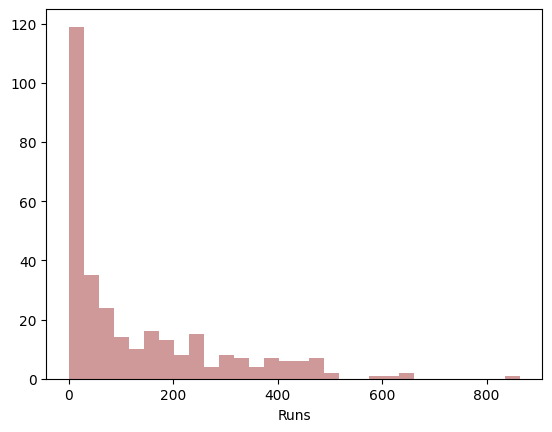

In [6]:
sns.distplot(df['Runs'].dropna(),kde=False,color='darkred',bins=30)

<Axes: >

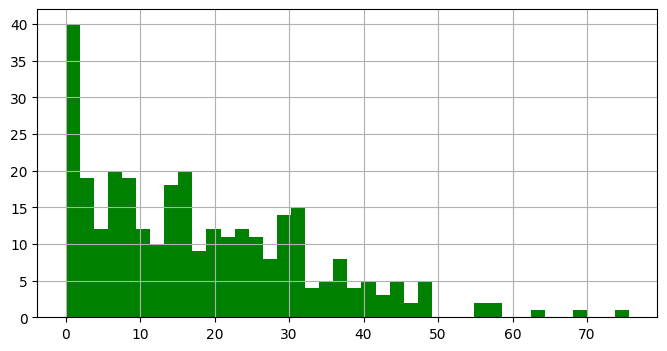

In [7]:
df['Avg'].hist(color='green',bins=40,figsize=(8,4))

In [8]:
x = df[['Avg','Mat','BF','SR','100','50','4s','6s']]
y = df[['Runs']]

In [9]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

In [10]:
x_train.shape, x_test.shape

((248, 8), (62, 8))

In [11]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error

# Change to regressor
knn = KNeighborsRegressor(n_neighbors=1)
knn.fit(x_train, y_train)

# Predict
y_pred = knn.predict(x_test)

# Calculate MAE
mae = mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error (MAE):", mae)


Mean Absolute Error (MAE): 8.951612903225806


In [12]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error

# Use regressor instead of classifier
dtree = DecisionTreeRegressor()
dtree.fit(x_train, y_train)

# Predict
predictions = dtree.predict(x_test)

# Calculate MAE
mae = mean_absolute_error(y_test, predictions)
print("Mean Absolute Error (MAE):", mae)


Mean Absolute Error (MAE): 11.17741935483871


In [13]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# Use regressor instead of classifier
rfc = RandomForestRegressor(n_estimators=100, random_state=42)
rfc.fit(x_train, y_train)

# Predict
rfc_pred = rfc.predict(x_test)

# Calculate MAE
mae = mean_absolute_error(y_test, rfc_pred)
print("Mean Absolute Error (MAE):", mae)


C:\Users\Ananya\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Mean Absolute Error (MAE): 8.285645161290322


In [14]:
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error

svr = SVR()
svr.fit(x_train, y_train)
y_pred_svr = svr.predict(x_test)

mae = mean_absolute_error(y_test, y_pred_svr)
print("MAE:", mae)


MAE: 80.89019419670703


C:\Users\Ananya\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [15]:
import xgboost as xgb

In [16]:
xgb_train = xgb.DMatrix(x_train, y_train, enable_categorical=True)
xgb_test = xgb.DMatrix(x_test, y_test, enable_categorical=True)

In [17]:
n=50
params = {'objective': 'reg:squarederror','max_depth': 3,    'learning_rate': 0.1}
model = xgb.train(params=params,dtrain=xgb_train,num_boost_round=n)

In [18]:
preds = model.predict(xgb_test)
print(preds)

[  3.9583764 446.88998   260.03378   249.50345   417.76828   251.56784
 166.87093    35.95714     8.829089  305.2829    235.30743    44.404556
   4.235804    4.235804    3.9583764   4.235804  488.06198    49.837162
  39.5685     40.476566  217.76196   163.3053     85.08167    19.891176
 214.47409    50.94302   119.40107   385.74265     5.077333   11.319725
 140.24062   564.61096   170.28267     5.6570644 153.43503   164.6274
 307.57153   437.57977    18.677673  121.19482   301.98425   430.00256
  36.689564   11.337628    4.235804   19.666636   14.663166  466.1006
   3.9583764 222.566     133.7868     12.624931   76.563774  150.16368
  33.15816     6.039978    3.9583764  25.292973   19.95064    24.601357
  14.385738   61.911877 ]


In [19]:
preds=preds.astype(int)
print(preds)

[  3 446 260 249 417 251 166  35   8 305 235  44   4   4   3   4 488  49
  39  40 217 163  85  19 214  50 119 385   5  11 140 564 170   5 153 164
 307 437  18 121 301 430  36  11   4  19  14 466   3 222 133  12  76 150
  33   6   3  25  19  24  14  61]


In [20]:
from sklearn.metrics import mean_absolute_error

# MAE
mae = mean_absolute_error(y_test, preds)
print("Mean Absolute Error (MAE):", mae)




Mean Absolute Error (MAE): 8.080645161290322


In [21]:
feature_columns = ['Avg', 'Mat', 'BF', 'SR', '100', '50', '4s', '6s']
custom_input_df = pd.DataFrame([[57.53, 17, 579, 149.05, 4, 4, 83, 45]], columns=feature_columns)
custom_dmatrix = xgb.DMatrix(custom_input_df)
custom_prediction = model.predict(custom_dmatrix)
print("Predicted Runs:", custom_prediction[0])


Predicted Runs: 802.8792
